Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
!unzip data.zip -d dataset

Archive:  data.zip
  inflating: dataset/test/crack/03133.jpg  
  inflating: dataset/test/crack/03134.jpg  
  inflating: dataset/test/crack/03135.jpg  
  inflating: dataset/test/crack/03136.jpg  
  inflating: dataset/test/crack/03137.jpg  
  inflating: dataset/test/crack/03138.jpg  
  inflating: dataset/test/crack/03139.jpg  
  inflating: dataset/test/crack/03140.jpg  
  inflating: dataset/test/crack/03141.jpg  
  inflating: dataset/test/crack/03142.jpg  
  inflating: dataset/test/crack/03143.jpg  
  inflating: dataset/test/crack/03144.jpg  
  inflating: dataset/test/crack/03145.jpg  
  inflating: dataset/test/crack/03146.jpg  
  inflating: dataset/test/crack/03147.jpg  
  inflating: dataset/test/crack/03148.jpg  
  inflating: dataset/test/crack/03149.jpg  
  inflating: dataset/test/crack/03150.jpg  
  inflating: dataset/test/crack/03151.jpg  
  inflating: dataset/test/crack/03152.jpg  
  inflating: dataset/test/crack/03153.jpg  
  inflating: dataset/test/crack/03154.jpg  
  inflating: 

In [ ]:
# Your specific paths
DATA_DIR = '/content/dataset/train'
MODEL_SAVE_PATH = '/content/best_classifier_model.keras'

# Hyperparameters tailored for small datasets
BATCH_SIZE = 16
IMG_SIZE = (128, 128)
EPOCHS = 100

# Define your exact class names in ALPHABETICAL order
CLASS_NAMES = ['Crack', 'Non Crack']

In [ ]:
DATA_DIR

'/content/dataset/train'

In [ ]:
# Load training data (80%)
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Load validation data (20%)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print("Classes found by Keras:", train_dataset.class_names)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 2500 files belonging to 2 classes.
Using 2000 files for training.
Found 2500 files belonging to 2 classes.
Using 500 files for validation.
Classes found by Keras: ['crack', 'non crack']


In [ ]:
# Aggressive data augmentation for the 200 training images
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

# MobileNetV2 expects pixel values between -1 and 1
preprocess_input = applications.mobilenet_v2.preprocess_input

In [ ]:
# Handle the 100 (open manhole) vs 152 (pothole) imbalance
weight_for_0 = 252.0 / (2.0 * 100.0)
weight_for_1 = 252.0 / (2.0 * 152.0)

class_weights = {0: weight_for_0, 1: weight_for_1}
print("Class weights applied:", class_weights)

Class weights applied: {0: 1.26, 1: 0.8289473684210527}


In [ ]:
# Load pre-trained MobileNetV2 (without the top layer)
base_model = applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False

# Build the final model architecture
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Callbacks to save the best model and prevent overfitting
checkpoint = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

print("Phase 1: Training the top layer...")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Phase 1: Training the top layer...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.7970 - loss: 0.4277
Epoch 1: val_accuracy improved from None to 0.99200, saving model to /content/best_classifier_model.keras

Epoch 1: finished saving model to /content/best_classifier_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 358ms/step - accuracy: 0.9320 - loss: 0.1640 - val_accuracy: 0.9920 - val_loss: 0.0409 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.9962 - loss: 0.0227
Epoch 2: val_accuracy did not improve from 0.99200
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 333ms/step - accuracy: 0.9945 - loss: 0.0243 - val_accuracy: 0.9920 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9960 - loss: 0.0168
Epoch 3: val_accuracy did not improve from 0.99200
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 358ms/step - accuracy: 0.9960 - loss: 0.0171 - val_accuracy: 0.9920 - val_loss: 0.0299 - learning

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Refreeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a 100x smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

print("\nPhase 2: Fine-tuning the last few layers...")
FINE_TUNE_EPOCHS = 15
total_epochs = len(history.epoch) + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=len(history.epoch),
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint]
)


Phase 2: Fine-tuning the last few layers...
Epoch 19/33
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.8299 - loss: 0.3342
Epoch 19: val_accuracy did not improve from 0.99800
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 461ms/step - accuracy: 0.8845 - loss: 0.2324 - val_accuracy: 0.9940 - val_loss: 0.0168
Epoch 20/33
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9732 - loss: 0.0782
Epoch 20: val_accuracy did not improve from 0.99800
125/125 ━━━━━━━━━━━━━━━━━━━━ 55s 440ms/step - accuracy: 0.9740 - loss: 0.0702 - val_accuracy: 0.9940 - val_loss: 0.0178
Epoch 21/33
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9876 - loss: 0.0384
Epoch 21: val_accuracy did not improve from 0.99800
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 424ms/step - accuracy: 0.9880 - loss: 0.0417 - val_accuracy: 0.9960 - val_loss: 0.0170
Epoch 22/33
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9797 - loss: 0.0460
Epoch 22: val_accuracy did not improve from 0.99800
125/125 ━━━━━━━━━━━━━━━━━━━━ 80

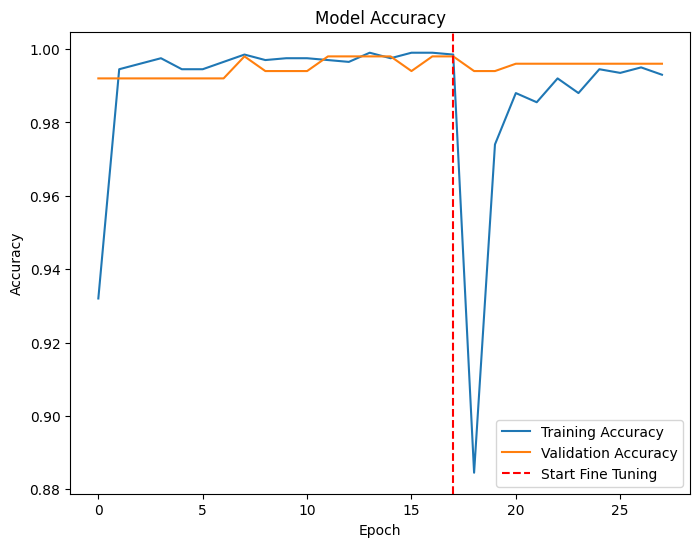

In [ ]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.epoch)-1, color='r', linestyle='--', label='Start Fine Tuning')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

Evaluation

In [ ]:
import tensorflow as tf

# Define the path to your saved model
MODEL_SAVE_PATH = '/content/best_classifier_model.keras'

# 1. Load your absolute best model
print("Loading best model...")
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

# 2. Evaluate the model on the validation dataset
# print("\nEvaluating model on validation data...")
# loss, accuracy = best_model.evaluate(val_dataset)

# # 3. Print the results clearly
# print("-" * 30)
# print(f"✅ Final Validation Accuracy: {accuracy * 100:.2f}%")
# print(f"📉 Final Validation Loss: {loss:.4f}")
# print("-" * 30)

Loading best model...


Load Model

In [ ]:
# 1. Load the absolute best model saved during training
Model_Save_Path = '/content/best_classifier_model.keras'
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("Best model loaded from disk successfully!")


Best model loaded from disk successfully!


Test Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Terminal Output -> Prediction: CRACK (Probability: 0.9998)


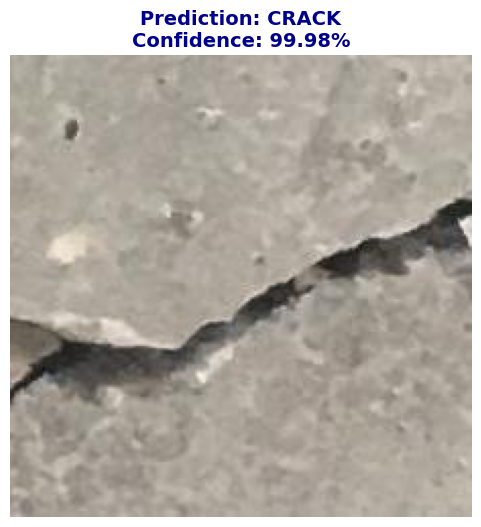

In [ ]:
CLASS_NAMES=['Crack', 'Non Crack']
IMG_SIZE = (128, 128)
def predict_and_display(image_path, model, classes):
    # Prepare image for the model
    img_for_model = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img_for_model)
    img_array = tf.expand_dims(img_array, 0)

    # Predict
    prediction = model.predict(img_array)
    prob = prediction[0][0]

    # Assign label based on probability
    if prob > 0.5:
        label = classes[1].upper() # POTHOLE
        confidence = prob
    else:
        label = classes[0].upper() # OPEN MANHOLE
        confidence = 1 - prob

    print(f"Terminal Output -> Prediction: {label} (Probability: {confidence:.4f})")

    # Display the original high-res image to the user
    original_img = tf.keras.preprocessing.image.load_img(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(original_img)
    plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()

# Test it on your screenshot
predict_and_display('/content/16256_1.jpg', best_model, CLASS_NAMES)